# Digital Communications — BPSK, QPSK & QAM

Analog modulation (AM/FM/PM) maps a continuous waveform onto a carrier. **Digital modulation** maps discrete **symbols** — each representing one or more bits — onto specific carrier states (amplitude, phase, or both).

Why digital?

- **Error correction**: redundant bits let the receiver detect and fix errors — impossible with analog
- **Compression**: source coding removes redundancy before transmission
- **Multiplexing**: time-division (TDMA) and code-division (CDMA) sharing are straightforward
- **Regeneration**: repeaters restore the signal to exact symbol values instead of amplifying noise

A digital modulator takes a bit stream, groups bits into **symbols** of $k$ bits each, and maps each symbol to a point in the **constellation** — a 2-D plane whose axes are the **in-phase** ($I$) and **quadrature** ($Q$) components of the carrier:

$$s(t) = I\cos(2\pi f_c t) - Q\sin(2\pi f_c t)$$

The constellation diagram is the single most important visualisation in digital comms — it shows every possible transmitted state and reveals how noise margins, bit assignments, and spectral efficiency trade off.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.special import erfc

%matplotlib inline
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

## BPSK — Binary Phase-Shift Keying

The simplest digital modulation: **1 bit per symbol**, two constellation points at $\pm 1$ on the real axis.

$$s(t) = \begin{cases} +\cos(2\pi f_c t) & \text{bit } 0 \\ -\cos(2\pi f_c t) & \text{bit } 1 \end{cases}$$

Equivalently, multiply the carrier by $\pm 1$: the phase flips by $\pi$ at every bit boundary where the data changes.

**Demodulation**: multiply by a synchronised carrier and integrate over one symbol period $T_s$. The result is positive or negative — threshold at zero recovers the bit.

**BER** (bit error rate) in AWGN:

$$\boxed{P_b^{BPSK} = \frac{1}{2}\operatorname{erfc}\!\left(\sqrt{\frac{E_b}{N_0}}\right)}$$

where $E_b/N_0$ is the energy per bit to noise spectral density ratio — the universal figure of merit for digital links. BPSK achieves the **best possible BER** for uncoded single-carrier modulation because its two constellation points are maximally separated for a given average power.

In [3]:
def plot_bpsk(num_bits=20, snr_db=10, fc=5, show_noise=True):
    rng = np.random.default_rng(42)
    bits = rng.integers(0, 2, num_bits)
    symbols = 2 * bits - 1  # 0 -> -1, 1 -> +1

    # --- Time-domain waveform ---
    sps = 200  # samples per symbol
    t_sym = 1.0
    t = np.linspace(0, num_bits * t_sym, num_bits * sps, endpoint=False)
    baseband = np.repeat(symbols, sps)
    carrier = np.cos(2 * np.pi * fc * t)
    tx = baseband * carrier

    # Add noise
    snr_lin = 10 ** (snr_db / 10)
    noise_std = 1 / np.sqrt(2 * snr_lin)
    noise_t = rng.normal(0, noise_std, len(t)) if show_noise else np.zeros(len(t))
    rx = tx + noise_t

    # --- Constellation with noise ---
    noise_iq = rng.normal(0, noise_std, num_bits) if show_noise else np.zeros(num_bits)
    rx_symbols = symbols + noise_iq

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Constellation
    ax = axes[0]
    ax.scatter(symbols, np.zeros(num_bits), s=120, c='steelblue', zorder=5,
               edgecolors='k', linewidths=0.8, label='Ideal')
    if show_noise:
        ax.scatter(rx_symbols, rng.normal(0, noise_std, num_bits),
                   s=30, c='salmon', alpha=0.7, label='Received')
    ax.axhline(0, color='k', lw=0.4)
    ax.axvline(0, color='k', lw=0.4)
    ax.set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), xlabel='In-phase (I)',
           ylabel='Quadrature (Q)', title='BPSK Constellation', aspect='equal')
    for b, x in zip([0, 1], [-1, 1]):
        ax.annotate(str(b), (x, 0.25), fontsize=14, ha='center', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Time-domain
    ax = axes[1]
    n_show = min(10, num_bits)
    idx = slice(0, n_show * sps)
    ax.plot(t[idx], rx[idx], color='salmon', lw=0.6, alpha=0.8, label='Received')
    ax.plot(t[idx], tx[idx], color='steelblue', lw=1.0, label='Transmitted')
    # Bit boundaries
    for i in range(n_show + 1):
        ax.axvline(i * t_sym, color='gray', ls=':', lw=0.6, alpha=0.5)
    # Bit labels
    for i in range(n_show):
        ax.text((i + 0.5) * t_sym, 1.35, str(bits[i]), ha='center', fontsize=9, color='purple')
    ax.set(xlabel='Time (s)', ylim=(-1.8, 1.8), title=f'BPSK waveform   Eb/N0 = {snr_db} dB')
    ax.legend(fontsize=9, loc='lower right')

    # Baseband
    ax = axes[2]
    ax.step(t[idx], baseband[idx], color='seagreen', lw=2, where='post')
    for i in range(n_show + 1):
        ax.axvline(i * t_sym, color='gray', ls=':', lw=0.6, alpha=0.5)
    for i in range(n_show):
        ax.text((i + 0.5) * t_sym, 1.25, str(bits[i]), ha='center', fontsize=9, color='purple')
    ax.set(xlabel='Time (s)', ylim=(-1.6, 1.6), title='Baseband NRZ symbol stream')
    ax.axhline(0, color='k', lw=0.4)

    plt.tight_layout()
    plt.show()

style = {'description_width': 'initial'}
widgets.interact(
    plot_bpsk,
    num_bits  =widgets.IntSlider(value=20, min=8, max=60, step=2, description='Num bits:', style=style),
    snr_db    =widgets.IntSlider(value=10, min=0, max=20, step=1, description='Eb/N0 (dB):', style=style),
    fc        =widgets.IntSlider(value=5, min=2, max=15, step=1, description='fc (cycles/sym):', style=style),
    show_noise=widgets.Checkbox(value=True, description='Show AWGN noise', style=style)
)

interactive(children=(IntSlider(value=20, description='Num bits:', max=60, min=8, step=2, style=SliderStyle(de…

<function __main__.plot_bpsk(num_bits=20, snr_db=10, fc=5, show_noise=True)>

## QPSK — Quadrature Phase-Shift Keying

QPSK doubles the spectral efficiency: **2 bits per symbol**, four constellation points at phases $\{45°, 135°, 225°, 315°\}$.

$$s(t) = I_k\cos(2\pi f_c t) - Q_k\sin(2\pi f_c t)$$

where $(I_k, Q_k) \in \{(\pm 1, \pm 1)\}/\sqrt{2}$ — each pair encodes a **dibit** (2 bits).

| Symbol | Bits (Gray) | Phase | $I$ | $Q$ |
|--------|-------------|-------|-----|-----|
| 0 | 00 | 45° | $+1/\sqrt{2}$ | $+1/\sqrt{2}$ |
| 1 | 01 | 135° | $-1/\sqrt{2}$ | $+1/\sqrt{2}$ |
| 2 | 11 | 225° | $-1/\sqrt{2}$ | $-1/\sqrt{2}$ |
| 3 | 10 | 315° | $+1/\sqrt{2}$ | $-1/\sqrt{2}$ |

**Gray coding** ensures adjacent constellation points differ by only 1 bit — so the most likely error (slipping to a neighbour) flips only 1 bit, not 2.

**Key insight**: QPSK is equivalent to two independent BPSK streams on $I$ and $Q$ channels. Each stream runs at half the bit rate, so QPSK achieves **the same BER as BPSK** at the same $E_b/N_0$, while carrying **twice the data per Hz**:

$$\boxed{P_b^{QPSK} = \frac{1}{2}\operatorname{erfc}\!\left(\sqrt{\frac{E_b}{N_0}}\right) = P_b^{BPSK}}$$

This is why QPSK is the default workhorse of satellite links, DVB-S, GPS L1, and LTE control channels.

In [4]:
def plot_qpsk(num_symbols=30, snr_db=10, show_noise=True):
    rng = np.random.default_rng(42)
    bits = rng.integers(0, 2, num_symbols * 2)
    # Gray mapping: 00->0, 01->1, 11->2, 10->3
    gray_map = {(0,0): 0, (0,1): 1, (1,1): 2, (1,0): 3}
    gray_labels = ['00', '01', '11', '10']
    phases = np.array([np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4])
    
    symbol_idx = np.array([gray_map[(bits[2*i], bits[2*i+1])] for i in range(num_symbols)])
    I_tx = np.cos(phases[symbol_idx])
    Q_tx = np.sin(phases[symbol_idx])

    snr_lin = 10 ** (snr_db / 10)
    noise_std = 1 / np.sqrt(2 * snr_lin)

    I_noise = rng.normal(0, noise_std, num_symbols) if show_noise else np.zeros(num_symbols)
    Q_noise = rng.normal(0, noise_std, num_symbols) if show_noise else np.zeros(num_symbols)
    I_rx = I_tx + I_noise
    Q_rx = Q_tx + Q_noise

    # --- Time-domain I/Q ---
    sps = 100
    t = np.linspace(0, num_symbols, num_symbols * sps, endpoint=False)
    I_wave = np.repeat(I_tx, sps)
    Q_wave = np.repeat(Q_tx, sps)

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Constellation
    ax = axes[0]
    # Ideal points
    for i, (lbl, ph) in enumerate(zip(gray_labels, phases)):
        ax.scatter(np.cos(ph), np.sin(ph), s=150, c='steelblue', zorder=5,
                   edgecolors='k', linewidths=0.8)
        ax.annotate(lbl, (np.cos(ph) + 0.12, np.sin(ph) + 0.12),
                    fontsize=13, fontweight='bold', color='navy')
    if show_noise:
        ax.scatter(I_rx, Q_rx, s=20, c='salmon', alpha=0.6, label='Received')
    # Decision boundaries
    ax.axhline(0, color='red', lw=1.0, ls='--', alpha=0.4)
    ax.axvline(0, color='red', lw=1.0, ls='--', alpha=0.4)
    ax.set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), xlabel='In-phase (I)',
           ylabel='Quadrature (Q)', title='QPSK Constellation (Gray coded)', aspect='equal')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # I/Q waveforms
    ax = axes[1]
    n_show = min(12, num_symbols)
    idx = slice(0, n_show * sps)
    ax.plot(t[idx], I_wave[idx], color='steelblue', lw=1.8, label='I channel')
    ax.plot(t[idx], Q_wave[idx], color='darkorange', lw=1.8, ls='--', label='Q channel')
    for i in range(n_show + 1):
        ax.axvline(i, color='gray', ls=':', lw=0.5, alpha=0.5)
    for i in range(n_show):
        b0, b1 = bits[2*i], bits[2*i+1]
        ax.text(i + 0.5, 1.25, f'{b0}{b1}', ha='center', fontsize=9, color='purple')
    ax.set(xlabel='Symbol period', ylim=(-1.6, 1.6),
           title=f'I/Q baseband   Eb/N0 = {snr_db} dB')
    ax.legend(fontsize=9)

    # Phase trajectory
    ax = axes[2]
    ph_tx = np.degrees(phases[symbol_idx])
    ax.step(range(n_show), ph_tx[:n_show], color='seagreen', lw=2.5, where='mid')
    ax.set(xlabel='Symbol index', ylabel='Phase (deg)',
           title='Transmitted phase per symbol',
           yticks=[45, 135, 225, 315],
           yticklabels=['45° (00)', '135° (01)', '225° (11)', '315° (10)'])
    ax.set_ylim(0, 360)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

style = {'description_width': 'initial'}
widgets.interact(
    plot_qpsk,
    num_symbols=widgets.IntSlider(value=30, min=10, max=80, step=5, description='Num symbols:', style=style),
    snr_db     =widgets.IntSlider(value=10, min=0, max=20, step=1, description='Eb/N0 (dB):', style=style),
    show_noise =widgets.Checkbox(value=True, description='Show AWGN noise', style=style)
)

interactive(children=(IntSlider(value=30, description='Num symbols:', max=80, min=10, step=5, style=SliderStyl…

<function __main__.plot_qpsk(num_symbols=30, snr_db=10, show_noise=True)>

## QAM — Quadrature Amplitude Modulation

PSK only varies phase. **QAM** varies both amplitude and phase, arranging constellation points on a rectangular grid. This packs more symbols into the same power budget.

For $M$-QAM with $M = 2^k$, each symbol carries $k = \log_2 M$ bits:

| Scheme | Grid | Bits/symbol | Spectral efficiency |
|--------|------|-------------|---------------------|
| 4-QAM (= QPSK) | $2\times 2$ | 2 | 2 bit/s/Hz |
| 16-QAM | $4\times 4$ | 4 | 4 bit/s/Hz |
| 64-QAM | $8\times 8$ | 6 | 6 bit/s/Hz |
| 256-QAM | $16\times 16$ | 8 | 8 bit/s/Hz |

The $I$ and $Q$ components each take values from $\{\pm 1, \pm 3, \ldots, \pm(\sqrt{M}-1)\}$, normalised to unit average power.

**BER approximation** for square $M$-QAM with Gray coding in AWGN:

$$\boxed{P_b \approx \frac{2\left(1 - \frac{1}{\sqrt{M}}\right)}{\log_2 M}\operatorname{erfc}\!\left(\sqrt{\frac{3\log_2 M}{2(M-1)}\cdot\frac{E_b}{N_0}}\right)}$$

**The fundamental trade-off**: higher $M$ → more bits/symbol → points closer together → needs higher $E_b/N_0$ for same BER. Wi-Fi 6 uses up to 1024-QAM; 5G NR goes to 256-QAM. Adaptive modulation and coding (AMC) picks the highest $M$ the channel can support.

In [5]:
def qam_constellation(M):
    """Generate Gray-coded M-QAM constellation, normalised to unit average power."""
    sqrt_M = int(np.sqrt(M))
    levels = np.arange(-(sqrt_M - 1), sqrt_M, 2, dtype=float)
    I_grid, Q_grid = np.meshgrid(levels, levels)
    I_pts = I_grid.ravel()
    Q_pts = Q_grid.ravel()
    # Normalise to unit average power
    avg_power = np.mean(I_pts**2 + Q_pts**2)
    I_pts /= np.sqrt(avg_power)
    Q_pts /= np.sqrt(avg_power)

    # Gray code labels
    def gray(n, bits):
        g = n ^ (n >> 1)
        return format(g, f'0{bits}b')
    bits_per_axis = int(np.log2(sqrt_M))
    labels = []
    for qi in range(sqrt_M):
        for ii in range(sqrt_M):
            labels.append(gray(ii, bits_per_axis) + gray(qi, bits_per_axis))
    return I_pts, Q_pts, labels


def plot_qam(M=16, snr_db=12, num_symbols=200):
    rng = np.random.default_rng(42)
    I_pts, Q_pts, labels = qam_constellation(M)
    k = int(np.log2(M))

    # Random symbols
    sym_idx = rng.integers(0, M, num_symbols)
    I_tx = I_pts[sym_idx]
    Q_tx = Q_pts[sym_idx]

    # Add noise
    snr_lin = 10 ** (snr_db / 10)
    # Eb/N0 to Es/N0: Es = k * Eb
    es_n0 = snr_lin * k
    noise_std = 1 / np.sqrt(2 * es_n0)
    I_rx = I_tx + rng.normal(0, noise_std, num_symbols)
    Q_rx = Q_tx + rng.normal(0, noise_std, num_symbols)

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    # Ideal constellation with labels
    ax = axes[0]
    ax.scatter(I_pts, Q_pts, s=100, c='steelblue', zorder=5, edgecolors='k', linewidths=0.6)
    lim = max(np.abs(I_pts).max(), np.abs(Q_pts).max()) * 1.4
    for i, lbl in enumerate(labels):
        ax.annotate(lbl, (I_pts[i], Q_pts[i] + lim * 0.04),
                    fontsize=max(5, 10 - k), ha='center', color='navy')
    ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), xlabel='I', ylabel='Q',
           title=f'{M}-QAM Constellation (Gray coded)\n{k} bits/symbol', aspect='equal')
    ax.grid(True, alpha=0.3)

    # Received with noise
    ax = axes[1]
    ax.scatter(I_rx, Q_rx, s=12, c='salmon', alpha=0.5, label='Received')
    ax.scatter(I_pts, Q_pts, s=60, c='steelblue', zorder=5, edgecolors='k',
               linewidths=0.5, label='Ideal')
    ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
    ax.set(xlim=(-lim * 1.5, lim * 1.5), ylim=(-lim * 1.5, lim * 1.5),
           xlabel='I', ylabel='Q',
           title=f'{M}-QAM   Eb/N0 = {snr_db} dB   ({num_symbols} symbols)', aspect='equal')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

style = {'description_width': 'initial'}
widgets.interact(
    plot_qam,
    M          =widgets.Dropdown(options=[4, 16, 64, 256], value=16, description='M-QAM:', style=style),
    snr_db     =widgets.IntSlider(value=12, min=0, max=30, step=1, description='Eb/N0 (dB):', style=style),
    num_symbols=widgets.IntSlider(value=200, min=50, max=1000, step=50, description='Num symbols:', style=style)
)

interactive(children=(Dropdown(description='M-QAM:', index=1, options=(4, 16, 64, 256), style=DescriptionStyle…

<function __main__.plot_qam(M=16, snr_db=12, num_symbols=200)>

## BER Curves — Theoretical & Monte Carlo

The **BER curve** (bit error rate vs $E_b/N_0$) is the ultimate performance metric for a digital modulation scheme. It answers: *how much power do I need per bit to achieve a target error rate?*

### Theoretical BER formulas (AWGN, Gray coding)

| Scheme | $P_b$ |
|--------|-------|
| BPSK / QPSK | $\frac{1}{2}\operatorname{erfc}\!\left(\sqrt{E_b/N_0}\right)$ |
| $M$-PSK | $\frac{1}{\log_2 M}\operatorname{erfc}\!\left(\sqrt{\log_2 M \cdot E_b/N_0}\sin\frac{\pi}{M}\right)$ |
| $M$-QAM | $\frac{2(1 - 1/\sqrt{M})}{\log_2 M}\operatorname{erfc}\!\left(\sqrt{\frac{3\log_2 M}{2(M-1)}\cdot E_b/N_0}\right)$ |

### Reading a BER curve

- **Waterfall region**: BER drops steeply — this is where the system operates
- **Error floor**: some channels/codes flatten out at low BER — not visible in pure AWGN
- **Coding gain**: forward error correction (FEC) shifts the curve left by 3–10 dB
- At BER $= 10^{-5}$, BPSK needs ~9.6 dB; 64-QAM needs ~17.8 dB — the price of 6× spectral efficiency

The Monte Carlo simulation below transmits random symbols, adds AWGN, detects, and counts errors — converging to the theoretical curve.

In [6]:
# --- Theoretical BER functions ---

def ber_bpsk(ebn0):
    return 0.5 * erfc(np.sqrt(ebn0))

def ber_qpsk(ebn0):
    return 0.5 * erfc(np.sqrt(ebn0))  # same as BPSK

def ber_mqam(ebn0, M):
    k = np.log2(M)
    return (2 * (1 - 1/np.sqrt(M)) / k) * erfc(np.sqrt(3 * k / (2 * (M - 1)) * ebn0))

def ber_mpsk(ebn0, M):
    k = np.log2(M)
    return (1 / k) * erfc(np.sqrt(k * ebn0) * np.sin(np.pi / M))


# --- Monte Carlo BER for M-QAM ---

def mc_ber_qam(M, ebn0_db_range, num_symbols=100000):
    """Monte Carlo BER for square M-QAM."""
    rng = np.random.default_rng(123)
    k = int(np.log2(M))
    sqrt_M = int(np.sqrt(M))
    levels = np.arange(-(sqrt_M - 1), sqrt_M, 2, dtype=float)

    # All constellation points (unnormalised)
    I_all, Q_all = np.meshgrid(levels, levels)
    I_all = I_all.ravel(); Q_all = Q_all.ravel()
    avg_pow = np.mean(I_all**2 + Q_all**2)
    I_all /= np.sqrt(avg_pow); Q_all /= np.sqrt(avg_pow)

    # Gray-coded bit labels
    def to_gray_bits(n, nbits):
        g = n ^ (n >> 1)
        return [(g >> (nbits - 1 - i)) & 1 for i in range(nbits)]
    nbits_ax = int(np.log2(sqrt_M))
    bit_table = np.zeros((M, k), dtype=int)
    for qi in range(sqrt_M):
        for ii in range(sqrt_M):
            idx = qi * sqrt_M + ii
            bit_table[idx] = to_gray_bits(ii, nbits_ax) + to_gray_bits(qi, nbits_ax)

    ber_list = []
    for ebn0_db in ebn0_db_range:
        ebn0 = 10 ** (ebn0_db / 10)
        es_n0 = ebn0 * k
        noise_std = 1 / np.sqrt(2 * es_n0)

        sym_idx = rng.integers(0, M, num_symbols)
        I_tx = I_all[sym_idx]
        Q_tx = Q_all[sym_idx]
        I_rx = I_tx + rng.normal(0, noise_std, num_symbols)
        Q_rx = Q_tx + rng.normal(0, noise_std, num_symbols)

        # Hard decision: nearest constellation point
        dist = (I_rx[:, None] - I_all[None, :])**2 + (Q_rx[:, None] - Q_all[None, :])**2
        det_idx = np.argmin(dist, axis=1)

        # Count bit errors
        tx_bits = bit_table[sym_idx]
        rx_bits = bit_table[det_idx]
        n_errors = np.sum(tx_bits != rx_bits)
        ber_list.append(n_errors / (num_symbols * k))

    return np.array(ber_list)


def plot_ber_curves(show_mc=True, mc_symbols=50000):
    ebn0_db = np.linspace(0, 25, 200)
    ebn0 = 10 ** (ebn0_db / 10)

    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 7))

    # Theoretical curves
    schemes = [
        ('BPSK / QPSK',  ber_bpsk(ebn0),        'steelblue',  '-'),
        ('8-PSK',         ber_mpsk(ebn0, 8),      'purple',     '-'),
        ('16-QAM',        ber_mqam(ebn0, 16),     'darkorange', '-'),
        ('64-QAM',        ber_mqam(ebn0, 64),     'seagreen',   '-'),
        ('256-QAM',       ber_mqam(ebn0, 256),    'crimson',    '-'),
    ]

    for name, ber, color, ls in schemes:
        ax.semilogy(ebn0_db, ber, color=color, ls=ls, lw=2.0, label=f'{name} (theory)')

    # Monte Carlo
    if show_mc:
        mc_db = np.arange(0, 22, 2)
        for M, color, marker in [(4, 'steelblue', 'o'), (16, 'darkorange', 's'),
                                  (64, 'seagreen', '^'), (256, 'crimson', 'D')]:
            mc_ber = mc_ber_qam(M, mc_db, num_symbols=mc_symbols)
            valid = mc_ber > 0
            label = f'{M}-QAM (MC, {mc_symbols//1000}k sym)'
            if M == 4:
                label = f'QPSK (MC, {mc_symbols//1000}k sym)'
            ax.semilogy(mc_db[valid], mc_ber[valid], marker=marker, color=color,
                        ls='none', ms=7, label=label, alpha=0.8)

    ax.set(xlabel='$E_b/N_0$ (dB)', ylabel='Bit Error Rate',
           title='BER Curves — Digital Modulation Schemes in AWGN',
           xlim=(0, 25), ylim=(1e-6, 0.5))
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=9, loc='lower left')

    # Reference lines
    for ber_ref, lbl in [(1e-3, 'Voice'), (1e-5, 'Data'), (1e-6, 'Video')]:
        ax.axhline(ber_ref, color='gray', ls=':', lw=0.8, alpha=0.5)
        ax.text(24.8, ber_ref * 1.3, lbl, fontsize=8, ha='right', color='gray')

    plt.tight_layout()
    plt.show()

style = {'description_width': 'initial'}
widgets.interact(
    plot_ber_curves,
    show_mc   =widgets.Checkbox(value=True, description='Show Monte Carlo points', style=style),
    mc_symbols=widgets.Dropdown(options=[10000, 50000, 200000], value=50000,
                                description='MC symbols:', style=style)
)

interactive(children=(Checkbox(value=True, description='Show Monte Carlo points', style=CheckboxStyle(descript…

<function __main__.plot_ber_curves(show_mc=True, mc_symbols=50000)>

## Eye Diagram

The **eye diagram** superimposes successive symbol periods on top of each other. It reveals timing jitter, noise margin, and inter-symbol interference (ISI) at a glance.

**How to read it:**

| Feature | Meaning |
|---------|---------|
| **Eye opening** (vertical) | Noise margin — taller = more robust |
| **Eye opening** (horizontal) | Timing margin — wider = less sensitive to clock jitter |
| **Crossing point spread** | Jitter — tighter = better clock recovery |
| **Thickness of traces** | Noise + ISI — thinner = cleaner channel |

A **raised-cosine** pulse shape is used to eliminate ISI (Nyquist criterion): the pulse is zero at all neighbouring sample instants. The **roll-off factor** $\alpha \in [0, 1]$ controls the trade-off between excess bandwidth and time-domain decay:

$$H(f) = \begin{cases} T_s & |f| \leq \frac{1-\alpha}{2T_s} \\ \frac{T_s}{2}\left[1 + \cos\left(\frac{\pi T_s}{\alpha}\left(|f| - \frac{1-\alpha}{2T_s}\right)\right)\right] & \frac{1-\alpha}{2T_s} < |f| \leq \frac{1+\alpha}{2T_s} \\ 0 & \text{otherwise} \end{cases}$$

- $\alpha = 0$: minimum bandwidth (sinc pulse) — zero ISI but infinite time support
- $\alpha = 1$: 100% excess bandwidth — faster decay, wider eye, easier to implement

In [7]:
def raised_cosine(t, T, alpha):
    """Raised-cosine pulse shape (time domain)."""
    p = np.zeros_like(t)
    for i, ti in enumerate(t):
        if ti == 0:
            p[i] = 1.0
        elif alpha > 0 and abs(abs(ti) - T / (2 * alpha)) < 1e-12:
            p[i] = (np.pi / (4 * T)) * np.sinc(1 / (2 * alpha))
        else:
            p[i] = np.sinc(ti / T) * np.cos(np.pi * alpha * ti / T) / (1 - (2 * alpha * ti / T)**2)
    return p


def plot_eye(modulation='BPSK', snr_db=15, alpha=0.35, num_symbols=200):
    rng = np.random.default_rng(42)
    sps = 32  # samples per symbol
    T = 1.0   # symbol period

    # Generate symbols
    if modulation == 'BPSK':
        symbols = 2 * rng.integers(0, 2, num_symbols) - 1.0
        n_levels = 2
    elif modulation == 'QPSK':
        bits = rng.integers(0, 2, num_symbols * 2)
        I_sym = 2 * bits[0::2] - 1.0
        Q_sym = 2 * bits[1::2] - 1.0
        symbols = I_sym  # show I channel eye
        n_levels = 2
    elif modulation == '4-PAM (16-QAM axis)':
        symbols = rng.choice([-3, -1, 1, 3], num_symbols).astype(float)
        symbols /= np.sqrt(np.mean(symbols**2))
        n_levels = 4
    else:
        symbols = rng.choice([-3, -1, 1, 3], num_symbols).astype(float)
        symbols /= np.sqrt(np.mean(symbols**2))
        n_levels = 4

    # Upsample
    sig_up = np.zeros(num_symbols * sps)
    sig_up[::sps] = symbols

    # Pulse shaping with raised-cosine
    span = 8  # symbols
    t_rc = np.arange(-span * sps, span * sps + 1) / sps * T
    rc_pulse = raised_cosine(t_rc, T, alpha)
    rc_pulse /= np.max(rc_pulse)

    sig_shaped = np.convolve(sig_up, rc_pulse, mode='same')

    # Add noise
    snr_lin = 10 ** (snr_db / 10)
    sig_power = np.mean(sig_shaped**2)
    noise_std = np.sqrt(sig_power / snr_lin)
    sig_noisy = sig_shaped + rng.normal(0, noise_std, len(sig_shaped))

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Pulse shape
    ax = axes[0]
    t_plot = t_rc / T
    ax.plot(t_plot, rc_pulse, color='steelblue', lw=2)
    ax.axhline(0, color='k', lw=0.4)
    for k in range(-span, span + 1):
        ax.axvline(k, color='gray', ls=':', lw=0.4, alpha=0.5)
    ax.scatter([0], [1], s=80, c='red', zorder=5)
    # Mark zero crossings at integer T
    for k in range(-span, span + 1):
        if k != 0:
            ax.scatter([k], [0], s=30, c='red', zorder=5, alpha=0.6)
    ax.set(xlabel='t / T', title=f'Raised-cosine pulse   alpha = {alpha}',
           xlim=(-4, 4), ylim=(-0.3, 1.15))

    # Eye diagram — clean
    ax = axes[1]
    start = span * sps
    end = len(sig_shaped) - span * sps
    for i in range(start, end - 2 * sps, sps):
        segment = sig_shaped[i:i + 2 * sps]
        t_eye = np.linspace(0, 2, len(segment))
        ax.plot(t_eye, segment, color='steelblue', lw=0.3, alpha=0.4)
    ax.axvline(1.0, color='red', ls='--', lw=1, alpha=0.5, label='Optimal sample')
    ax.set(xlabel='t / T', title=f'{modulation} Eye (no noise)')
    ax.legend(fontsize=9)

    # Eye diagram — noisy
    ax = axes[2]
    for i in range(start, end - 2 * sps, sps):
        segment = sig_noisy[i:i + 2 * sps]
        t_eye = np.linspace(0, 2, len(segment))
        ax.plot(t_eye, segment, color='salmon', lw=0.3, alpha=0.4)
    ax.axvline(1.0, color='red', ls='--', lw=1, alpha=0.5, label='Optimal sample')
    ax.set(xlabel='t / T', title=f'{modulation} Eye   Eb/N0 = {snr_db} dB')
    ax.legend(fontsize=9)

    plt.suptitle(f'{modulation}   alpha = {alpha}   {num_symbols} symbols', fontsize=11)
    plt.tight_layout()
    plt.show()

style = {'description_width': 'initial'}
widgets.interact(
    plot_eye,
    modulation =widgets.Dropdown(options=['BPSK', 'QPSK', '4-PAM (16-QAM axis)'],
                                  value='BPSK', description='Modulation:', style=style),
    snr_db     =widgets.IntSlider(value=15, min=0, max=30, step=1, description='Eb/N0 (dB):', style=style),
    alpha      =widgets.FloatSlider(value=0.35, min=0.0, max=1.0, step=0.05,
                                     description='Roll-off alpha:', style=style),
    num_symbols=widgets.IntSlider(value=200, min=50, max=500, step=50, description='Num symbols:', style=style)
)

interactive(children=(Dropdown(description='Modulation:', options=('BPSK', 'QPSK', '4-PAM (16-QAM axis)'), sty…

<function __main__.plot_eye(modulation='BPSK', snr_db=15, alpha=0.35, num_symbols=200)>

## Spectral Efficiency vs Required $E_b/N_0$  — The Shannon Limit

Every modulation scheme trades spectral efficiency $\eta$ [bit/s/Hz] for required SNR. The **Shannon limit** sets the theoretical boundary — no scheme can operate below this curve reliably:

$$\eta < \log_2\!\left(1 + \frac{E_b}{N_0}\cdot\eta\right)$$

or equivalently, the minimum $E_b/N_0$ for a given $\eta$:

$$\frac{E_b}{N_0}\bigg|_{\min} = \frac{2^\eta - 1}{\eta}$$

At $\eta \to 0$, the Shannon limit approaches $-1.59$ dB — the absolute minimum energy per bit for reliable communication. Real systems operate 3–10 dB above the limit; modern LDPC and turbo codes get within 0.5 dB.

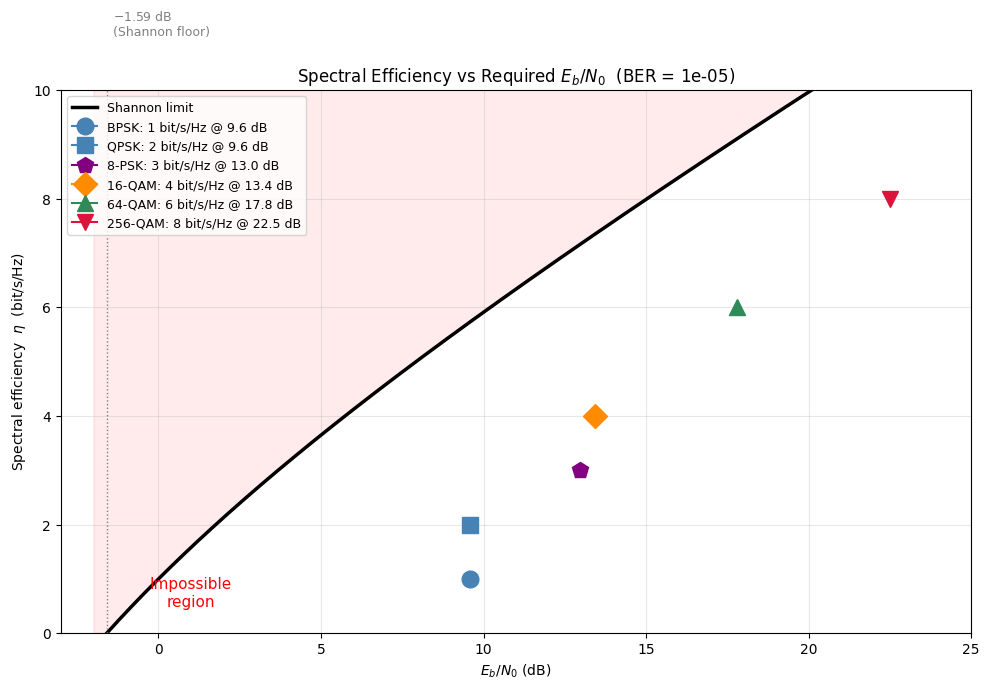

In [8]:
def plot_shannon():
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 7))

    # Shannon limit curve
    eta = np.linspace(0.01, 12, 500)
    ebn0_min = (2**eta - 1) / eta
    ebn0_min_db = 10 * np.log10(ebn0_min)
    ax.plot(ebn0_min_db, eta, 'k-', lw=2.5, label='Shannon limit')
    ax.fill_betweenx(eta, -2, ebn0_min_db, alpha=0.08, color='red')
    ax.text(1, 0.5, 'Impossible\nregion', fontsize=11, color='red', ha='center')

    # Modulation schemes at BER = 1e-5
    target_ber = 1e-5
    schemes = []

    # BPSK/QPSK: erfc(sqrt(ebn0)) / 2 = target
    from scipy.optimize import brentq
    from scipy.special import erfcinv
    ebn0_bpsk = (erfcinv(2 * target_ber))**2
    schemes.append(('BPSK', 1, ebn0_bpsk))
    schemes.append(('QPSK', 2, ebn0_bpsk))

    # 8-PSK
    def f8psk(ebn0): return (1/3) * erfc(np.sqrt(3 * ebn0) * np.sin(np.pi/8)) - target_ber
    ebn0_8psk = brentq(f8psk, 0.1, 100)
    schemes.append(('8-PSK', 3, ebn0_8psk))

    # M-QAM
    for M in [16, 64, 256]:
        k = np.log2(M)
        def fqam(ebn0, M=M, k=k):
            return (2*(1 - 1/np.sqrt(M))/k) * erfc(np.sqrt(3*k/(2*(M-1)) * ebn0)) - target_ber
        ebn0_mqam = brentq(fqam, 0.1, 1000)
        schemes.append((f'{M}-QAM', k, ebn0_mqam))

    colors = ['steelblue', 'steelblue', 'purple', 'darkorange', 'seagreen', 'crimson']
    markers = ['o', 's', 'p', 'D', '^', 'v']

    for (name, eta_val, ebn0_val), col, mk in zip(schemes, colors, markers):
        ebn0_db = 10 * np.log10(ebn0_val)
        ax.plot(ebn0_db, eta_val, marker=mk, color=col, ms=12, zorder=5,
                label=f'{name}: {eta_val:.0f} bit/s/Hz @ {ebn0_db:.1f} dB')

    # Shannon limit at -1.59 dB
    ax.axvline(-1.59, color='gray', ls=':', lw=1)
    ax.text(-1.4, 11, '$-1.59$ dB\n(Shannon floor)', fontsize=9, color='gray')

    ax.set(xlabel='$E_b/N_0$ (dB)', ylabel='Spectral efficiency  $\\eta$  (bit/s/Hz)',
           title=f'Spectral Efficiency vs Required $E_b/N_0$  (BER = {target_ber:.0e})',
           xlim=(-3, 25), ylim=(0, 10))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')

    plt.tight_layout()
    plt.show()

plot_shannon()